# Action Recognition with an Inflated 3D CNN (using tf hub)


## Instrucciones Generales

El siguiente práctico es **individual**. El formato de entregar es el **archivo .ipynb con todas las celdas ejecutadas**. Todas las preguntas deben ser respondida en celdas de texto. No se aceptará el _output_ de una celda de código como respuesta.

**Nombre:** Roberto Araneda Espinoza

**Fecha de entrega:**

El siguiente práctico cuanta con varias secciones y al final 1 o más actividades a realizar. Algunas actividades correspondrán a escribir código y otras a responder preguntas.

**Importante.** Para facilitar su ejecución, cada sección puede ser ejecutada independientemente.

Se recomienda **fuertemente** revisar las secciones donde se entrega código porque algunas actividades de código pueden reutilizar el mismo código pero con cambios en algunas líneas.

## 1.0 Introducción

El objetivo del reconocimiento de actividad humana es examinar actividades a partir de secuencias de video o imágenes fijas. Uno de los modelos más importantes en esta área se describe en el artículo "[Quo Vadis, Action Recognition? A New
Model and the Kinetics Dataset](https://arxiv.org/abs/1705.07750)" de Joao Carreira y Andrew Zisserman. El artículo fue publicado como un documento de conferencia en CVPR 2017.

El artículo "Quo Vadis" introdujo una nueva arquitectura para la clasificación de video, la Red Neuronal Convolucional Ampliada en 3D o I3D. Esta arquitectura logró resultados de última generación en los conjuntos de datos UCF101 y HMDB51 mediante el ajuste fino de estos modelos. Los modelos I3D pre-entrenados en Kinetics también ocuparon el primer lugar en el desafío Charades de CVPR 2017. [Charades challenge](http://vuchallenge.org/charades.html).

El módulo original fue entrenado en el conjunto de datos [kinetics-400 dateset](https://deepmind.com/research/open-source/open-source-datasets/kinetics/)
 y reconoce alrededor de 400 acciones diferentes.


En este tutorial utilizaremos el modelo I3D para reconocer actividades en videos de un conjunto de datos UCF101 y datos propios. Utilizaremos TensorFlow Hub porque permite utilizar el modelo pre-entrenado de una manera sencilla.

Based on: https://tfhub.dev/deepmind/i3d-kinetics-400/1

## 2.0 Setup

La línea de código !pip install -q imageio es un comando de instalación utilizando **pip, que es el sistema de gestión de paquetes de Python**. La opción **-q significa "quiet"**, lo que hace que **la salida de la instalación sea silenciosa**, es decir, no se mostrarán mensajes de progreso ni información adicional durante la instalación.

En este caso, el** paquete imageio** se está instalando. **Este paquete es una biblioteca de Python para leer y escribir una amplia gama de formatos de archivos de imagen y video.** Una vez instalado, se puede utilizar en el código Python para trabajar con imágenes y videos de manera eficiente.

**opencv-python** es un paquete de Python que proporciona funciones para procesar imágenes y videos. Es una interfaz de Python para OpenCV (Open Source Computer Vision Library), que es una biblioteca de software de visión por computadora de código abierto ampliamente utilizada. OpenCV proporciona una amplia gama de herramientas y algoritmos para tareas como reconocimiento de objetos, seguimiento de objetos, detección de rostros, calibración de cámaras, entre otros.

El paquete **opencv-python **facilita el uso de OpenCV desde Python, proporcionando enlaces a las funciones de OpenCV para manipular imágenes y videos de una manera fácil y eficiente. Puedes realizar operaciones como cargar, guardar, procesar y analizar imágenes y videos utilizando las funciones proporcionadas por opencv-python.

In [1]:
!pip install -q imageio
!pip install -q opencv-python
!pip install -q git+https://github.com/tensorflow/docs

  Preparing metadata (setup.py) ... done


* **tensorflow (abreviado como tf):**TensorFlow es una biblioteca de
código abierto desarrollada por Google para realizar cálculos numéricos y construir y entrenar modelos de aprendizaje automático, especialmente para redes neuronales profundas. En este código, TensorFlow se utiliza para cargar y ejecutar modelos de aprendizaje automático, así como para realizar operaciones de manipulación de datos.

* **tensorflow_hub (abreviado como hub):** TensorFlow Hub es una biblioteca que proporciona un repositorio de modelos de aprendizaje automático pre-entrenados, así como herramientas para cargar y utilizar estos modelos de manera eficiente. En este código, tensorflow_hub se utiliza para cargar un modelo pre-entrenado desde TensorFlow Hub.

* **absl.logging:** absl es una biblioteca de utilidades de Google que proporciona funciones para mejorar la experiencia de registro en Python. En este código, se utiliza para configurar el nivel de verbosidad del registro a ERROR, lo que significa que solo se mostrarán mensajes de error y no mensajes de advertencia o información.

* **random, re, os, tempfile, ssl, cv2, numpy:** Estos son módulos estándar de Python que se utilizan para realizar diversas tareas, como manipulación de archivos, manejo de rutas de archivo, generación de números aleatorios, procesamiento de imágenes, manipulación de matrices y más.
* **imageio, IPython.display, urllib.request:** Estos módulos se utilizan para mostrar animaciones y cargar datos desde la web en el entorno de IPython. imageio se utiliza para trabajar con imágenes y videos, IPython.display se utiliza para mostrar imágenes y videos en el entorno de IPython, y urllib.request se utiliza para realizar solicitudes web y descargar datos desde Internet.

In [2]:
# TensorFlow and TF-Hub modules.
from absl import logging

import tensorflow as tf
import tensorflow_hub as hub
from tensorflow_docs.vis import embed

logging.set_verbosity(logging.ERROR)

# Some modules to help with reading the UCF101 dataset.
import random
import re
import os
import tempfile
import ssl
import cv2
import numpy as np

# Some modules to display an animation using imageio.
import imageio
from IPython import display

from urllib import request  # requires python3

### 2.1 Definiendo utilidades para recuperar el conjunto de datos UCF101

Las siguientes funciones permiten obtener videos del conjunto de datos UCF101 desde el repositorio original:

* **list_ucf_videos** devuelve la lista de los videos disponibles.
* **fetch_ucf_video** devuelve un video seleccionado, para lo cual necesitas proporcionar el nombre del video.

**Nota:** Una vez conectado el drive sube la carpeta y reemplaza la nueva ubicación de tu carpeta en la variable `VIDEO_DIR`  



In [3]:
!wget --no-check-certificate https://www.crcv.ucf.edu/data/UCF101/UCF101.rar

--2026-08-09 22:22:30--  https://www.crcv.ucf.edu/data/UCF101/UCF101.rar
Resolving www.crcv.ucf.edu (www.crcv.ucf.edu)... 132.170.214.127
Connecting to www.crcv.ucf.edu (www.crcv.ucf.edu)|132.170.214.127|:443... connected.
  Unable to locally verify the issuer's authority.
HTTP request sent, awaiting response... 200 OK
Length: 6932971618 (6.5G) [application/x-rar-compressed]
Saving to: ‘UCF101.rar’

UCF101.rar          100%[===================>]   6.46G  42.5MB/s    in 2m 27s  

2026-08-09 22:24:57 (45.1 MB/s) - ‘UCF101.rar’ saved [6932971618/6932971618]



In [4]:
!unrar x '/content/UCF101.rar'

Se han truncado las últimas 5000 líneas del flujo de salida.
Extracting  UCF-101/PlayingGuitar/v_PlayingGuitar_g06_c05.avi             62%  OK 
Extracting  UCF-101/PlayingGuitar/v_PlayingGuitar_g06_c06.avi             62%  OK 
Extracting  UCF-101/PlayingGuitar/v_PlayingGuitar_g06_c07.avi             62%  OK 
Extracting  UCF-101/PlayingGuitar/v_PlayingGuitar_g07_c01.avi             62%  OK 
Extracting  UCF-101/PlayingGuitar/v_PlayingGuitar_g07_c02.avi             62%  OK 
Extracting  UCF-101/PlayingGuitar/v_PlayingGuitar_g07_c03.avi             62%  OK 
Extracting  UCF-101/PlayingGuitar/v_PlayingGuitar_g07_c04.avi             62%  OK 
Extracting  UCF-101/PlayingGuitar/v_PlayingGuitar_g07_c05.avi             62%  OK 
Extracting  UCF-101/PlayingGuitar/v_PlayingGuitar_g07_c06.avi             62%  OK 
Extracting  UCF-101/PlayingGuitar/v_PlayingGuitar_g07_c07.avi             62%  OK 
Extracting  UCF-101

In [5]:
# Utilities to fetch videos from UCF101 dataset

VIDEO_DIR = '/content/UCF-101'
_CACHE_DIR = tempfile.mkdtemp()
def fetch_ucf_video(video):
  """Fetchs a video and cache into local filesystem."""
  cache_path = os.path.join(_CACHE_DIR, video)
  if not os.path.exists(cache_path):
    urlpath = request.urljoin(UCF_ROOT, video)
    print("Fetching %s => %s" % (urlpath, cache_path))
    data = request.urlopen(urlpath, context=unverified_context).read()
    open(cache_path, "wb").write(data)
  return cache_path

In [6]:
import os
import re
from collections import defaultdict

def list_ucf_videos(video_dir):
    """
    Lists AVI videos available in the UCF101 dataset from a specified local directory,
    including all subdirectories, and groups them by category.

    Args:
        video_dir (str): Path to the directory containing the UCF101 video files.

    Returns:
        dict: Dictionary with categories as keys and a list of video filenames as values.
    """
    if not os.path.exists(video_dir):
        raise ValueError(f"Provided directory does not exist: {video_dir}")
    if not os.path.isdir(video_dir):
        raise ValueError(f"Provided path is not a directory: {video_dir}")

    category_videos = defaultdict(list)
    # Walk through all subdirectories
    for root, dirs, files in os.walk(video_dir):
        category_name = os.path.basename(root)  # Get the name of the directory
        for filename in files:
            # Check if the file is an AVI video
            if re.match(r"^v_.*\.avi$", filename):
                category_videos[category_name].append(filename)

    # Sort and format the output
    for category in sorted(category_videos):
        videos = category_videos[category]
        videos.sort()
        num_videos = len(videos)
        sample_videos = ', '.join(videos[:min(3, num_videos)]) + ', ...' if num_videos > 3 else ', '.join(videos)
        print(f"{category:<20} {num_videos} videos ({sample_videos})")

Las siguientes funciones te permiten cargar un video para alimentar el modelo.

In [7]:
# Utilities to open video files using CV2
def crop_center_square(frame):
  y, x = frame.shape[0:2]
  min_dim = min(y, x)
  start_x = (x // 2) - (min_dim // 2)
  start_y = (y // 2) - (min_dim // 2)
  return frame[start_y:start_y+min_dim,start_x:start_x+min_dim]

def load_video(path, max_frames=0, resize=(224, 224)):
  cap = cv2.VideoCapture(path)
  frames = []
  try:
    while True:
      ret, frame = cap.read()
      if not ret:
        break
      frame = crop_center_square(frame)
      frame = cv2.resize(frame, resize)
      frame = frame[:, :, [2, 1, 0]]
      frames.append(frame)

      if len(frames) == max_frames:
        break
  finally:
    cap.release()
  return np.array(frames) / 255.0

La función **to_gif** convierte un video a un gif.

In [8]:
def to_gif(images):
  converted_images = np.clip(images * 255, 0, 255).astype(np.uint8)
  imageio.mimsave('./animation.gif', converted_images, fps=25)
  return embed.embed_file('./animation.gif')

## 3.0 Procesando UCF101 Dataset

Obtenemos la lista de videos del conjunto de datos y luego la imprimimos para mayor conveniencia.




In [9]:
# Get the list of videos in the dataset.
ucf_videos = list_ucf_videos(VIDEO_DIR)


ApplyEyeMakeup       145 videos (v_ApplyEyeMakeup_g01_c01.avi, v_ApplyEyeMakeup_g01_c02.avi, v_ApplyEyeMakeup_g01_c03.avi, ...)
ApplyLipstick        114 videos (v_ApplyLipstick_g01_c01.avi, v_ApplyLipstick_g01_c02.avi, v_ApplyLipstick_g01_c03.avi, ...)
Archery              145 videos (v_Archery_g01_c01.avi, v_Archery_g01_c02.avi, v_Archery_g01_c03.avi, ...)
BabyCrawling         132 videos (v_BabyCrawling_g01_c01.avi, v_BabyCrawling_g01_c02.avi, v_BabyCrawling_g01_c03.avi, ...)
BalanceBeam          108 videos (v_BalanceBeam_g01_c01.avi, v_BalanceBeam_g01_c02.avi, v_BalanceBeam_g01_c03.avi, ...)
BandMarching         155 videos (v_BandMarching_g01_c01.avi, v_BandMarching_g01_c02.avi, v_BandMarching_g01_c03.avi, ...)
BaseballPitch        150 videos (v_BaseballPitch_g01_c01.avi, v_BaseballPitch_g01_c02.avi, v_BaseballPitch_g01_c03.avi, ...)
Basketball           134 videos (v_Basketball_g01_c01.avi, v_Basketball_g01_c02.avi, v_Basketball_g01_c03.avi, ...)
BasketballDunk       131 videos (v_B

El beneficio de utilizar la función **fetch_ucf_video** es que no necesitamos descargar todo el conjunto de datos porque descarga una muestra específica.

Luego, utilizando la función **load_video**, obtenemos una muestra para usar con el modelo I3D. Ten en cuenta que podemos usar la función **to_gif** para visualizar el video.

**Nota:** En el caso del video_path , debes de buscar la direccion en donde se encuentra el video, o simplemente puedes escoger cualquier video para realizar la prueba. Pero siempre asegúrate de colocar bien la dirección

In [10]:
# Get a sample video.
video_path = fetch_ucf_video("/content/UCF-101/ApplyEyeMakeup/v_ApplyEyeMakeup_g01_c01.avi")
sample_video = load_video(video_path)

* 164 fotogramas.
* Cada fotograma tiene una resolución de 224 píxeles de alto por 224 píxeles de ancho.
* Cada píxel tiene 3 canales de color (correspondientes a los canales rojo, verde y azul, respectivamente).

In [11]:
sample_video.shape

(164, 224, 224, 3)


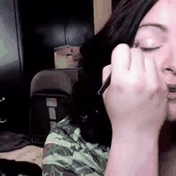

In [12]:
to_gif(sample_video)

## 4.0 Cargando y utilizando un modelo pre-entrenado

Primero, necesitamos obtener las etiquetas para nuestro modelo. El modelo I3D fue entrenado en Kinetics-400, por esa razón tenemos 400 etiquetas.




In [13]:
# Get the kinetics-400 action labels from the GitHub repository.
KINETICS_URL = "https://raw.githubusercontent.com/deepmind/kinetics-i3d/master/data/label_map.txt"
with request.urlopen(KINETICS_URL) as obj:
  labels = [line.decode("utf-8").strip() for line in obj.readlines()]
print("Found %d labels." % len(labels))

Found 400 labels.


TensorFlow Hub es un repositorio de modelos de aprendizaje automático entrenados listos para el fine-tuning  y desplegables en cualquier lugar. En este tutorial, trabajamos con un modelo de Convnet 3D ampliado (I3D) entrenado para el reconocimiento de acciones en Kinetics-400.

La siguiente línea carga el modelo listo para ser utilizado para predicciones.


In [14]:
i3d = hub.load("https://tfhub.dev/deepmind/i3d-kinetics-400/1").signatures['default']

Definimos una función que permite obtener las probabilidades y mostrar las 5 principales predicciones.

In [15]:
def predict(sample_video):
  # Add a batch axis to the to the sample video.
  model_input = tf.constant(sample_video, dtype=tf.float32)[tf.newaxis, ...]

  logits = i3d(model_input)['default'][0]
  probabilities = tf.nn.softmax(logits)

  print("Top 5 actions:")
  k=5
  for i in np.argsort(probabilities)[::-1][:k]:
    print(f"  {labels[i]:22}: {probabilities[i] * 100:5.2f}%")

Ejecuta el modelo I3D e imprime las 5 principales predicciones de acción.

In [16]:
predict(sample_video)

Top 5 actions:
  filling eyebrows      : 98.13%
  applying cream        :  1.57%
  waxing eyebrows       :  0.17%
  playing harmonica     :  0.07%
  brush painting        :  0.04%


## 5.0 Predecir con datos propios

Podemos utilizar cualquier video descargado de Internet para predecir la acción con el modelo I3D.

Intentemoslo con [este video](https://huggingface.co/datasets/nateraw/video-demo/resolve/main/archery.mp4) de Hugging Face:

In [17]:
!wget https://huggingface.co/datasets/nateraw/video-demo/resolve/main/archery.mp4

--2026-08-09 22:26:59--  https://huggingface.co/datasets/nateraw/video-demo/resolve/main/archery.mp4
Resolving huggingface.co (huggingface.co)... 18.164.174.23, 18.164.174.118, 18.164.174.17, ...
Connecting to huggingface.co (huggingface.co)|18.164.174.23|:443... connected.
HTTP request sent, awaiting response... 307 Temporary Redirect
Location: /api/resolve-cache/datasets/nateraw/video-demo/8e566ce5b7c2fd05f61fb2b2fe4f2520706607d1/archery.mp4?%2Fdatasets%2Fnateraw%2Fvideo-demo%2Fresolve%2Fmain%2Farchery.mp4=&etag=%224a724d6f1c804338b442c9a9890e80502d710a08%22 [following]
--2026-08-09 22:26:59--  https://huggingface.co/api/resolve-cache/datasets/nateraw/video-demo/8e566ce5b7c2fd05f61fb2b2fe4f2520706607d1/archery.mp4?%2Fdatasets%2Fnateraw%2Fvideo-demo%2Fresolve%2Fmain%2Farchery.mp4=&etag=%224a724d6f1c804338b442c9a9890e80502d710a08%22
Reusing existing connection to huggingface.co:443.
HTTP request sent, awaiting response... 200 OK
Length: 549197 (536K) [video/mp4]
Saving to: ‘archery.mp4

In [18]:
video_path = "archery.mp4"

In [19]:
sample_video = load_video(video_path)[:100]


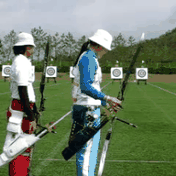

In [20]:
to_gif(sample_video)

In [21]:
predict(sample_video)

Top 5 actions:
  archery               : 99.28%
  throwing axe          :  0.32%
  flying kite           :  0.11%
  catching or throwing frisbee:  0.05%
  pole vault            :  0.04%


## 6.0 Actividad

Ahora es tu turno. Reutiliza el código de la sección 5.0 para predecir la acción del siguiente video: https://github.com/bryanyzhu/tiny-ucf101/raw/master/abseiling_k400.mp4

**Verificar que tenga el siguiente codigo (2puntos)**

shape: (250, 224, 224, 3)



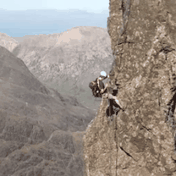

Top 5 actions:
  rock climbing         : 87.66%
  abseiling             : 11.23%
  ice climbing          :  1.02%
  diving cliff          :  0.05%
  bungee jumping        :  0.02%


In [22]:
# Escribe tu código aqui
# ============ ACTIVIDAD: reconocer la acción en abseiling_k400.mp4 ============
# Se reutiliza el pipeline de la sección 5.0: descargar → cargar → visualizar → predecir.

# 1) Descargar el video
!wget -q https://github.com/bryanyzhu/tiny-ucf101/raw/master/abseiling_k400.mp4

# 2) Definir la ruta
video_path = "abseiling_k400.mp4"

# 3) Cargar y preprocesar (crop central → resize 224×224 → BGR→RGB → /255)
sample_video = load_video(video_path)
print("shape:", sample_video.shape)

# 4) Visualizar (1 de cada 2 frames, para no inflar el .ipynb)
display.display(to_gif(sample_video[::2]))

# 5) Predecir con el modelo I3D pre-entrenado en Kinetics-400
predict(sample_video)

In [24]:
# ================== ¿Por qué I3D confunde abseiling con rock climbing? ==================
import pandas as pd

def leer_frames(path):
    """Frames RGB uint8, SIN crop ni resize."""
    cap = cv2.VideoCapture(path); fs = []
    while True:
        ret, f = cap.read()
        if not ret: break
        fs.append(f[:, :, ::-1])          # BGR → RGB
    cap.release()
    return np.array(fs)                    # (T, H, W, 3) uint8

def recortar(fr, modo="centro", size=224):
    T, H, W, _ = fr.shape
    if modo == "notebook":                 # lo que hace load_video: crop cuadrado + resize
        m = min(H, W); x0 = (W//2)-(m//2); y0 = (H//2)-(m//2)
        c = fr[:, y0:y0+m, x0:x0+m]
        return np.stack([cv2.resize(f, (size, size), interpolation=cv2.INTER_AREA) for f in c])
    y0 = (H - size)//2                     # protocolo oficial: crop 224 directo
    x0 = {"izq": 0, "der": W - size}.get(modo, (W - size)//2)
    return fr[:, y0:y0+size, x0:x0+size]

def normalizar(fr, rango="0_1"):
    a = fr.astype(np.float32)
    return a/255.0 if rango == "0_1" else a/127.5 - 1.0

I_ABS, I_ROCK = labels.index("abseiling"), labels.index("rock climbing")

def evaluar(video, etiqueta):
    x = tf.constant(video, dtype=tf.float32)[tf.newaxis, ...]
    p = tf.nn.softmax(i3d(x)['default'][0]).numpy()
    o = np.argsort(p)[::-1]
    return {"experimento": etiqueta, "frames": video.shape[0],
            "top-1": labels[o[0]], "p top-1 %": round(float(p[o[0]])*100, 2),
            "p abseiling %": round(float(p[I_ABS])*100, 2),
            "p rock climb %": round(float(p[I_ROCK])*100, 2),
            "rank abseiling": int(np.where(o == I_ABS)[0][0]) + 1,
            "H (nats)": round(float(-np.sum(p*np.log(p+1e-12))), 3)}

fr = leer_frames("abseiling_k400.mp4")
print("video crudo:", fr.shape)            # esperado (250, 256, 455, 3)
res = []

# --- H1: rango de entrada [0,1] vs [-1,1] ---
base = recortar(fr, "notebook")
res.append(evaluar(normalizar(base, "0_1"),  "H1 · notebook + rango [0,1]  (baseline)"))
res.append(evaluar(normalizar(base, "m1_1"), "H1 · notebook + rango [-1,1] (DeepMind)"))

# --- H2: protocolo de crop oficial (224 directo, sin reescalar) ---
ofi = recortar(fr, "centro")
res.append(evaluar(normalizar(ofi, "0_1"),  "H2 · crop224 directo + [0,1]"))
res.append(evaluar(normalizar(ofi, "m1_1"), "H2 · crop224 directo + [-1,1]"))

# --- H3: multi-crop espacial (se descarta ~44% del ancho) ---
for m in ["izq", "centro", "der"]:
    res.append(evaluar(normalizar(recortar(fr, m), "m1_1"), f"H3 · crop224 {m:6} + [-1,1]"))

# --- H4: ventana y muestreo temporal ---
o = recortar(fr, "centro")
for nom, sub in [("primeros 64 (como GluonCV)", o[:64]),
                 ("primeros 64, stride 2",      o[0:64:2]),
                 ("centrales 100",              o[75:175]),
                 ("últimos 100",                o[150:]),
                 ("completo stride 2 (12.5fps)",o[::2]),
                 ("completo (250)",             o)]:
    res.append(evaluar(normalizar(sub, "m1_1"), f"H4 · {nom}"))

# --- H5: ¿I3D codifica la DIRECCIÓN del movimiento? ---
res.append(evaluar(normalizar(o[::-1], "m1_1"), "H5 · video INVERTIDO en el tiempo"))

df = pd.DataFrame(res)
pd.set_option("display.width", 200); pd.set_option("display.max_colwidth", 45)
display.display(df)


video crudo: (250, 256, 454, 3)


,experimento,frames,top-1,p top-1 %,p abseiling %,p rock climb %,rank abseiling,H (nats)
0,"H1 · notebook + rango [0,1] (baseline)",250,rock climbing,88.02,10.86,88.02,2,0.408
1,"H1 · notebook + rango [-1,1] (DeepMind)",250,abseiling,62.31,62.31,37.68,1,0.664
2,"H2 · crop224 directo + [0,1]",250,rock climbing,87.14,11.46,87.14,2,0.430
3,"H2 · crop224 directo + [-1,1]",250,abseiling,65.19,65.19,34.75,1,0.651
4,"H3 · crop224 izq + [-1,1]",250,rock climbing,32.99,9.26,32.99,4,2.753
5,"H3 · crop224 centro + [-1,1]",250,abseiling,65.19,65.19,34.75,1,0.651
6,"H3 · crop224 der + [-1,1]",250,abseiling,75.28,75.28,24.59,1,0.570
7,H4 · primeros 64 (como GluonCV),64,abseiling,92.85,92.85,7.11,1,0.260
8,"H4 · primeros 64, stride 2",32,abseiling,87.06,87.06,12.86,1,0.390
9,H4 · centrales 100,100,abseiling,58.46,58.46,41.52,1,0.680


In [25]:
# ============ Configuración corregida vs. baseline del tutorial ============
def logits_de(video):
    x = tf.constant(video, dtype=tf.float32)[tf.newaxis, ...]
    return i3d(x)['default'][0].numpy()

fr64 = leer_frames("abseiling_k400.mp4")[:64]          # ventana inicial (H4)

# promedio de logits sobre los 3 crops horizontales (H3) con rango [-1,1] (H1)
L = np.mean([logits_de(normalizar(recortar(fr64, m), "m1_1"))
             for m in ["izq", "centro", "der"]], axis=0)
p = tf.nn.softmax(L).numpy(); o = np.argsort(p)[::-1][:5]

print("=== Protocolo corregido: [-1,1] + 3-crop + primeros 64 frames ===")
for i in o:
    print(f"  {labels[i]:22}: {p[i]*100:5.2f}%")
print(f"\n  entropía = {-np.sum(p*np.log(p+1e-12)):.3f} nats")
print(f"  vs baseline del tutorial: rock climbing 88.02% / abseiling 10.86% (H=0.408)")

# --- Y revisamos si el rango [-1,1] también cambia los otros dos videos ---
for path, nombre, esperada in [
    ("/content/UCF-101/ApplyEyeMakeup/v_ApplyEyeMakeup_g01_c01.avi", "ApplyEyeMakeup", None),
    ("archery.mp4", "archery", "archery")]:
    f = leer_frames(path)
    for rango in ["0_1", "m1_1"]:
        p2 = tf.nn.softmax(logits_de(normalizar(recortar(f, "notebook"), rango))).numpy()
        o2 = np.argsort(p2)[::-1][:3]
        print(f"\n{nombre} · {rango}: " + " | ".join(f"{labels[i]} {p2[i]*100:.2f}%" for i in o2))


=== Protocolo corregido: [-1,1] + 3-crop + primeros 64 frames ===
  abseiling             : 75.46%
  rock climbing         : 24.19%
  paragliding           :  0.27%
  ice climbing          :  0.07%
  motorcycling          :  0.00%

  entropía = 0.578 nats
  vs baseline del tutorial: rock climbing 88.02% / abseiling 10.86% (H=0.408)

ApplyEyeMakeup · 0_1: filling eyebrows 98.23% | applying cream 1.48% | waxing eyebrows 0.16%

ApplyEyeMakeup · m1_1: filling eyebrows 79.50% | applying cream 19.44% | waxing eyebrows 1.04%

archery · 0_1: archery 99.66% | catching or throwing frisbee 0.05% | throwing axe 0.05%

archery · m1_1: archery 99.97% | throwing axe 0.01% | javelin throw 0.00%


In [23]:
# ---- Comparación cuantitativa de los tres videos evaluados ----
import pandas as pd

def analizar(path, nombre, clase_esperada, max_frames=0):
    v = load_video(path, max_frames=max_frames)
    x = tf.constant(v, dtype=tf.float32)[tf.newaxis, ...]
    p = tf.nn.softmax(i3d(x)['default'][0]).numpy()
    orden = np.argsort(p)[::-1]
    H = float(-np.sum(p * np.log(p + 1e-12)))
    en_vocab = clase_esperada in labels
    return {
        "video": nombre,
        "frames": v.shape[0],
        "clase esperada": clase_esperada,
        "¿en Kinetics-400?": "sí" if en_vocab else "NO",
        "top-1": labels[orden[0]],
        "prob top-1 (%)": round(float(p[orden[0]]) * 100, 2),
        "rank clase esperada": (int(np.where(orden == labels.index(clase_esperada))[0][0]) + 1) if en_vocab else "—",
        "entropía (nats)": round(H, 3),
    }

filas = [
    analizar("/content/UCF-101/ApplyEyeMakeup/v_ApplyEyeMakeup_g01_c01.avi",
             "ApplyEyeMakeup (UCF101)", "applying eye makeup"),
    analizar("archery.mp4", "archery (HuggingFace)", "archery", max_frames=100),
    analizar("abseiling_k400.mp4", "abseiling (Kinetics demo)", "abseiling"),
]
df = pd.DataFrame(filas)
print(f"Entropía máxima posible = ln(400) = {np.log(400):.3f} nats\n")
display.display(df)


Entropía máxima posible = ln(400) = 5.991 nats



,video,frames,clase esperada,¿en Kinetics-400?,top-1,prob top-1 (%),rank clase esperada,entropía (nats)
0,ApplyEyeMakeup (UCF101),164,applying eye makeup,NO,filling eyebrows,98.13,—,0.104
1,archery (HuggingFace),100,archery,sí,archery,99.28,1,0.060
2,abseiling (Kinetics demo),250,abseiling,sí,rock climbing,87.66,2,0.415


### Hallazgos experimentales

Al ejecutar la actividad, el modelo predijo **`rock climbing` (87,66 %)** en vez de
`abseiling` (11,23 %, rank #2). Se diagnosticó la causa con cinco experimentos controlados:

| Hipótesis | Resultado | Conclusión |
|---|---|---|
| **H1** Rango de entrada `[0,1]` vs `[-1,1]` | 10,86 % → **62,31 %**, top-1 cambia | **Causa principal** |
| **H2** `crop256+resize` vs `crop224` directo | +2,9 pts | Marginal |
| **H3** Crop izq / centro / der | 9,3 % / 65,2 % / **75,3 %**; H=2,75 en izq | El sujeto no está centrado |
| **H4** Ventana temporal | primeros 64: **92,9 %**; últimos 100: 39,4 % ❌ | Gradiente temporal fuerte |
| **H5** Video invertido en el tiempo | 65,2 % → 67,2 % (sin cambio) | I3D **no** usa la dirección del tiempo |

**Causa raíz (H1):** el notebook normaliza a `[0,1]` con `np.array(frames)/255.0`, pero el repo
oficial de DeepMind (`google-deepmind/kinetics-i3d`) especifica *"pixel values are then rescaled
between -1 and 1"*. I3D hereda las capas BatchNorm de Inception-v1, calibradas sobre entradas
centradas en cero; alimentarlo con `[0,1]` introduce un sesgo constante de +0,5 que se propaga
por toda la red. El error no destruye el modelo: `archery` acierta igual (99,66 % vs 99,97 %).
Sólo se manifiesta en la frontera de decisión entre clases visualmente vecinas.

**Validación externa:** la demo oficial de GluonCV usa este mismo video y reporta
`abseiling` con 99,1 %, usando 32 frames de la ventana inicial y crop central de 224 — coherente
con H1 y H4.

**Sobre H5:** invertir temporalmente el video no cambia la predicción, pese a que rápel invertido
*es* escalada. I3D discrimina por apariencia y movimiento de corto alcance (cuerda, arnés,
postura), no por la dirección del movimiento. Esto es consistente con el sesgo de apariencia
documentado en Kinetics-400 y con la motivación del dataset Something-Something.


Basado en este tutorial y en la clase responde las preguntas:


### 1.¿El modelo I3D es un modelo 3D o 2D?
Respuesta 1:

I3D es un modelo **3D**: todas sus capas son convoluciones y poolings tridimensionales, con kernels
de forma `t × k × k` que se deslizan simultáneamente sobre las dimensiones de tiempo, alto y ancho.
Su entrada es un tensor 5D `[batch, frames, alto, ancho, canales]` — en este práctico,
`(1, 250, 224, 224, 3)` — algo que una CNN 2D no puede procesar sin destruir el eje temporal.

Sin embargo, **su origen es 2D**, y de ahí viene su nombre: la "I" es de *Inflated*. Carreira y
Zisserman no diseñaron una arquitectura 3D nueva, sino que tomaron una **Inception-v1 ya entrenada
en ImageNet** e "inflaron" cada filtro: un kernel 2D de `k × k` se replica `t` veces a lo largo del
eje temporal y se **divide por `t`**. Esa división garantiza que, ante un video de imagen congelada
(el mismo frame repetido), la red 3D produzca activaciones numéricamente idénticas a las de la red
2D original — lo que el paper llama el *boring video fixed point*. La red inflada arranca
reproduciendo exactamente una CNN de ImageNet y sólo debe aprender la componente de movimiento.

Encontré **evidencia experimental directa de esa herencia 2D**. Al comparar rangos de entrada, el
video de rápel se clasifica como `rock climbing` (88,02 %) si se normaliza a `[0,1]` —como hace el
notebook—, pero la predicción se invierte a `abseiling` (62,31 %) al normalizar a `[-1,1]`, que es
el rango que especifica el repositorio oficial de DeepMind. La explicación es que I3D **hereda las
capas BatchNorm de Inception-v1**, cuyas estadísticas fueron calibradas con entradas centradas en
cero. El modelo es tan literalmente una red 2D inflada que arrastra incluso las estadísticas de
normalización de su versión para imágenes.

En resumen: I3D es **3D en su funcionamiento y 2D en su inicialización**, y es esa combinación la
que le permite heredar el conocimiento visual de ImageNet en vez de entrenar desde cero.

### 2.¿El modelo I3D es un enfoque de modelo recortado (trimmed model approach)?

Respuesta 2:

Sí, I3D es un enfoque **trimmed** (de video recortado). La distinción relevante es:

- **Trimmed:** clips cortos (~10 s) ya recortados de modo que la acción ocupa todo el clip. La tarea
  es de **clasificación**: un clip produce una etiqueta. Ejemplos: Kinetics, UCF101, HMDB51.
- **Untrimmed:** videos largos en los que la acción ocupa un segmento temporal desconocido. La tarea
  es de **detección o localización temporal**: hay que decir qué acción ocurre y entre qué instantes.
  Ejemplos: THUMOS14, ActivityNet.

I3D pertenece al primer grupo, por tres razones verificables en este mismo práctico:

**1. Su salida no tiene eje temporal.** El modelo devuelve un tensor `[1, 400]`: un único vector de
clases para el clip completo, porque aplica *average pooling* sobre el tiempo antes de la capa de
clasificación. No puede indicar **cuándo** ocurre la acción, sólo **qué** acción hay, asumiendo que
hay una y que dura todo el clip.

**2. Fue entrenado y evaluado sobre datasets recortados.** Kinetics-400 está formado por clips de
~10 s recortados manualmente; UCF101 y HMDB51 también son recortados. El video de la actividad dura
exactamente 10,00 s a 25 fps: los parámetros canónicos de un clip de Kinetics.

**3. Medí el costo de esa suposición.** Evaluando distintas ventanas temporales del mismo video obtuve:

| Ventana | Frames | p(`abseiling`) | Top-1 |
|---|---|---|---|
| Primeros 64 (0–2,6 s) | 64 | **92,85 %** | `abseiling` |
| Centrales 100 (3–7 s) | 100 | 58,46 % | `abseiling` |
| Últimos 100 (6–10 s) | 100 | 39,36 % | `rock climbing` (falla) |
| Video completo | 250 | 65,19 % | `abseiling` |

Existe un gradiente temporal claro: el inicio del clip es inequívocamente rápel y el final se parece
a una escalada. Promediar sobre los 10 s completos **diluye la evidencia buena del inicio con la
evidencia ambigua del final**, y como el promediado ocurre sobre los logits dentro de la red, esa
información ya no se puede recuperar.

Esto ilustra exactamente la limitación *trimmed*: I3D supone que toda la ventana que recibe contiene
la acción. Cuando no es así, no se equivoca "un poco" — puede invertir la predicción. Para video
untrimmed, I3D se emplea entonces como **extractor de características** sobre ventanas deslizantes,
con una cabeza adicional encargada de la localización temporal.

### 3.Menciona al menos una ventaja del I3D sobre los enfoques anteriores:

Respuesta 3:

**Ventaja principal: el inflado resuelve el cuello de botella de datos.**

Una CNN 3D tiene muchos más parámetros que su equivalente 2D, porque cada kernel se multiplica por
el tamaño temporal; pero los datasets de video eran órdenes de magnitud menores que ImageNet. C3D
(Tran, 2015) tenía **78 millones de parámetros entrenados desde cero** sobre los ~13.000 videos de
UCF101, con el sobreajuste garantizado que eso implica.

El inflado rompe ese círculo: I3D **hereda los pesos de ImageNet** y opera con unos **12 millones de
parámetros — 6,5 veces menos que C3D —** obteniendo resultados muy superiores (**98,0 %** en UCF101
frente a ~88 % del estado del arte previo, y **80,9 %** en HMDB51 frente a ~67 %). No hacen falta
millones de videos anotados porque las primeras capas —bordes, texturas, partes de objetos— ya se
aprendieron con imágenes fijas; la red sólo debe aprender la componente temporal. Como beneficio
adicional, al ser el inflado una operación mecánica aplicable a cualquier CNN 2D, la arquitectura
hereda gratis todo el progreso futuro en diseño de redes de imagen, algo imposible para C3D.

**Ventaja adicional: representaciones transferibles de alta calidad.**

En este práctico, sin ningún entrenamiento, el modelo pre-entrenado clasificó `archery.mp4` con
**99,97 %** de confianza. Sus cuatro competidores en el top-5 —`throwing axe`, `flying kite`,
`catching or throwing frisbee` y `pole vault`— comparten el mismo patrón cinemático de brazos
extendidos, objeto alargado y gesto de lanzar. El espacio de representación agrupa acciones por
**estructura del movimiento**, no por contexto ni por objeto, que es justamente lo que se espera de
filtros espacio-temporales aprendidos end-to-end. Los enfoques previos no lo lograban: la CNN 2D con
pooling (Karpathy, 2014) ignora el orden de los frames; Two-Stream (Simonyan, 2014) precomputa el
flujo óptico **fuera** de la red, de forma cara y no aprendible; y LRCN (Donahue, 2015) colapsa cada
frame a un vector antes de que el LSTM lo procese, perdiendo el movimiento local.

**Dos matices que también encontré experimentalmente.**

Sobre `ApplyEyeMakeup`, cuya clase **no existe** en Kinetics-400, el modelo predijo `filling
eyebrows` con **98,23 %** de confianza. Un modelo pre-entrenado sólo puede responder dentro de su
vocabulario, y el softmax le impide expresar "no lo sé". Por eso el propio paper *Quo Vadis*
reemplaza la capa final de 400 salidas por una de 101 y hace fine-tuning para alcanzar el 98,0 % en
UCF101: el pre-entrenamiento entrega un extractor de características excelente, no un clasificador
directamente utilizable.

Al invertir temporalmente el video de rápel, la predicción prácticamente no cambió (65,19 % → 67,22 %
para `abseiling`), pese a que un rápel invertido es visualmente una escalada. Esto sugiere que I3D
discrimina estas dos clases por apariencia y movimiento de corto alcance —la cuerda, el arnés, la
postura— más que por la dirección del movimiento. Es coherente con el sesgo de apariencia
documentado en Kinetics-400 y con la motivación del dataset Something-Something. La arquitectura 3D
**habilita** el razonamiento temporal, pero el dataset no siempre lo **exige**.
